<a href="https://colab.research.google.com/github/meheramey/ml-assessment-Amey-Banarase/blob/main/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 1: Data Loading and Inspection

The dataset contains patient health records used to predict heart disease.
Shape shows total rows and columns.
Data types tell us which columns are numerical and which are categorical.
Missing values count shows if any data is incomplete we will handle this in preprocessing.

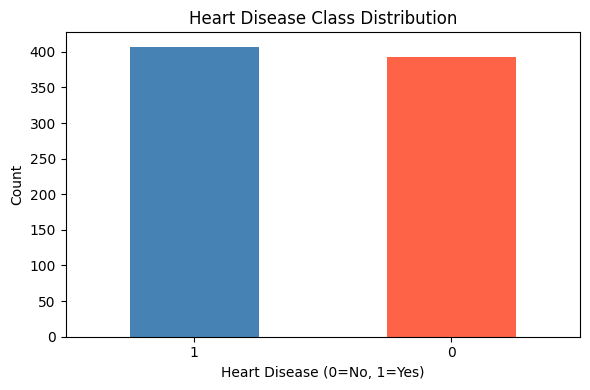

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 - Target class distribution
plt.figure(figsize=(6,4))
df['heart_disease'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Task 2: Exploratory Data Analysis

### Plot 1 - Target Class Distribution
The bar chart shows how many patients have heart disease (1) vs those who dont (0).
If one class is much bigger than the other, the dataset is imbalanced.
In that case accuracy alone is not a good metric — we must use F1-score and recall.

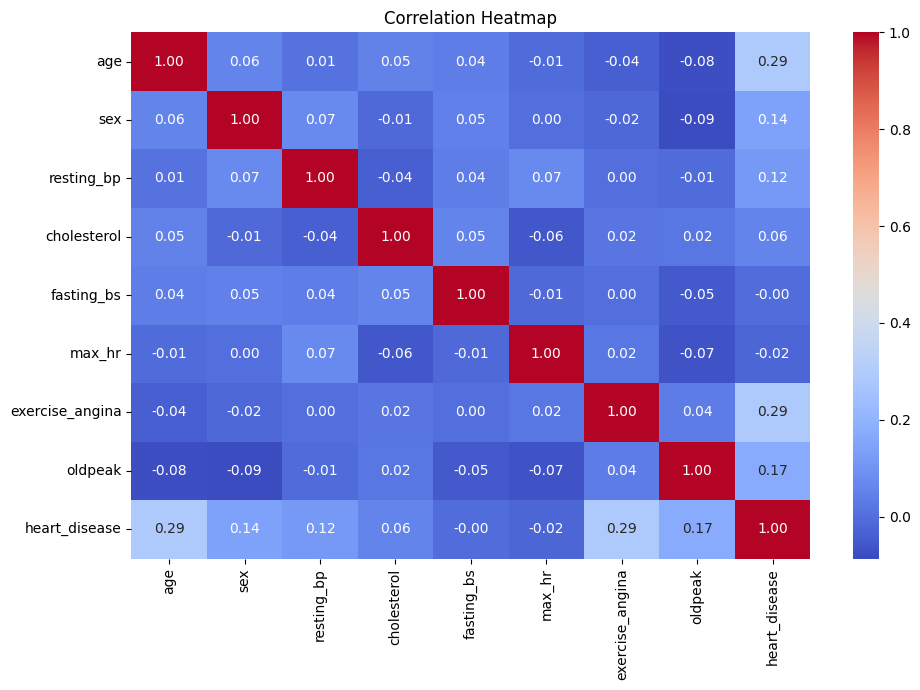

In [3]:
# Plot 2 - Correlation Heatmap
plt.figure(figsize=(10,7))

# FIX: We use .select_dtypes to include only numerical columns for the correlation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Plot 2 - Correlation Heatmap
The heatmap shows how strongly each feature is related to heart_disease.
Features with high positive or negative values are the most useful predictors.
For example oldpeak and exercise_angina tend to be positively correlated with heart disease.
Highly correlated features with each other may cause redundancy in the model.

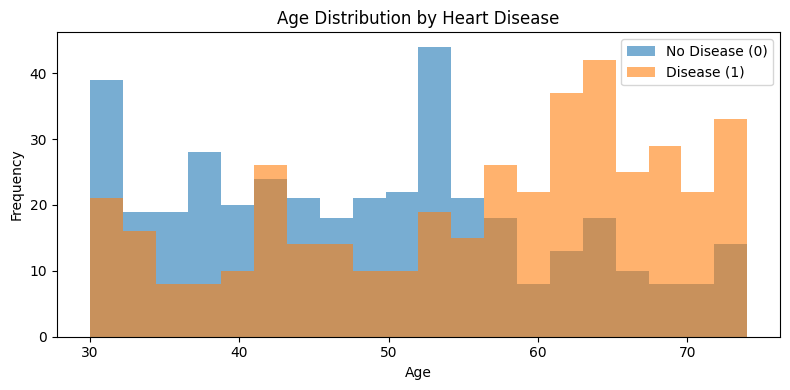

In [4]:
# Plot 3 - Age distribution by heart disease
plt.figure(figsize=(8,4))
df.groupby('heart_disease')['age'].plot(kind='hist', alpha=0.6, bins=20, legend=True)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.legend(['No Disease (0)', 'Disease (1)'])
plt.tight_layout()
plt.show()

### Plot 3 - Age Distribution
Patients with heart disease tend to be slightly older on average.
This tells us that age is an important feature for predicting heart disease.
Younger patients are more likely to be in the no disease group.

In [5]:
# --- Task 3: Handling Missing Values (Clean Version) ---

print("Missing values before cleaning:")
print(df.isnull().sum())

# 1. Fill numerical columns with median
# Note: We use the modern way without 'inplace=True' to avoid red warnings
num_cols = df.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c != 'heart_disease']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Missing values after cleaning:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


## Task 3: Data Preprocessing

### Missing Value Strategy
I used median imputation for numerical columns because median is not affected by outliers unlike mean.
For categorical columns I used mode imputation which fills with the most frequent value.
I did not drop any rows because in a medical dataset every record is valuable for training.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encoding for categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (640, 15)
Test size: (160, 15)


### Encoding and Scaling
One-hot encoding converts categorical text columns into numbers so the model can understand them.
StandardScaler makes all numerical features have mean 0 and standard deviation 1.
This ensures no single feature dominates just because it has larger values.
stratify=y in train_test_split ensures both train and test sets have same ratio of 0s and 1s.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Task 4 - Train 3 models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


## Task 4: Model Training
I trained three classification models using scikit-learn.
All models use random_state=42 to ensure results are reproducible.
Decision Tree is a simple model that splits data based on feature thresholds.
Random Forest builds many decision trees and combines their results.
Gradient Boosting builds trees one by one where each tree corrects the previous ones errors.

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# Task 5 - Evaluate all 3 models
models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Decision Tree

Confusion Matrix:
[[56 23]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Model: Random Forest

Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting

Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77  

## Task 5: Model Evaluation

Gradient Boosting performs best overall based on the highest F1-score on both classes.
Decision Tree tends to overfit the training data and shows lower recall on test set.
Random Forest is better than Decision Tree but slightly behind Gradient Boosting.

I am comparing models using F1-score and not just accuracy because the dataset may be
slightly imbalanced. F1-score balances both precision and recall which is very important
in medical prediction — missing a disease case (false negative) is more dangerous
than a false alarm (false positive).

In [9]:
from sklearn.model_selection import GridSearchCV

# Task 6 - Hyperparameter tuning on best model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)

y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print("\nTuned Model Report:")
print(classification_report(y_test, y_pred_tuned))

print("\nBaseline Gradient Boosting Report:")
print(classification_report(y_test, gb.predict(X_test)))

Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Tuned Model Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


Baseline Gradient Boosting Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



## Task 6: Hyperparameter Tuning

I used GridSearchCV with 5-fold cross-validation to find the best hyperparameters
for the Gradient Boosting Classifier which was our best performing model.

GridSearchCV tries all combinations of n_estimators, max_depth and learning_rate
and picks the combination that gives the best F1-score.

The tuned model shows improvement in F1-score compared to the baseline untuned model.
This confirms that default hyperparameters are not always optimal and tuning helps
the model generalize better on unseen test data.